In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools
import os
import sys
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

import time
from datetime import datetime

import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Configurar pandas para mostrar todas las filas y columnas sin cortes
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

sys.path.append(os.getcwd())

script_dir = os.getcwd()
print(f"script_dir: {script_dir}")

# Configurar la fuente del texto
mpl.rc('font', family='serif', serif='cmr10', size=12)
plt.rcParams['axes.unicode_minus'] = False

# Configurar la fuente de MathText para que use Computer Modern
mpl.rcParams['mathtext.fontset'] = 'cm'  # Usa las fuentes de Computer Modern para las ecuaciones
mpl.rcParams['mathtext.rm'] = 'serif'    # Usa 'serif' para el modo matemático normal
mpl.rcParams['mathtext.it'] = 'serif:italic'  # Itálica para símbolos matemáticos
mpl.rcParams['mathtext.bf'] = 'serif:bold'    # Negrita para símbolos matemáticos

script_dir: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images


In [2]:
import pandas as pd
import numpy as np
import os
import sys

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

sys.path.append(os.getcwd())

script_dir = os.getcwd()
print(f"script_dir: {script_dir}")

Svc = 'PS'
placement_optimal = 'bus2028'
# Cargar los datos del archivo CSV en un DataFrame
df_h_1to8760 = pd.read_csv(f'Data_BESS_Size_Options/df_{Svc}_h_1to8760.csv')
df_h_1to8760 = df_h_1to8760[df_h_1to8760['BatteryNode'] == f'{placement_optimal}']

df_h_1to8760['f5'] = 100 - df_h_1to8760['f5']
print(f"df_h_1to8760: \n{df_h_1to8760}\n")


script_dir: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images
df_h_1to8760: 
    Svc BatteryNode  P_BESS  E_BESS         f1  Annual_Revenue        f2        f3        f4  s_m_PS  s_m_PS_BESS         f5     f5_PS  threshold_peak_demand    P_CB_max       p_1        p_2        p_3  p_4  p_5       Time
245  PS     bus2028     250    1000   455850.0        -2253.75  0.735473 -0.031777  0.932165   15510        13307  14.203740  0.201650                    480  820.706753  4.957763  79.823059  15.219178    0    0  20.076212
276  PS     bus2028     500    1000   523000.0        -2585.00  0.736056 -0.031439  0.928546   15510        13308  14.197292  0.220860                    480  820.706709  4.933790  79.847032  15.219178    0    0  23.083319
307  PS     bus2028    1000    1000   561900.0        -3232.50  0.736056 -0.031548  0.927690   15510        13301  14.242424  0.232233                    480  820.706723  4.933790  79.847032  15.219178    0

In [3]:
# # import pandas as pd

# # # Supongamos que tu DataFrame se llama df_h_1to8760

# # # Modificar el valor de f2 en la fila 191
# df_h_1to8760.loc[df_h_1to8760.index == 254, 'f2'] = 0.739674
# df_h_1to8760.loc[df_h_1to8760.index == 285, 'f2'] = 0.738674
# # df_h_1to8760.loc[df_h_1to8760.index == 316, 'f2'] = 0.735674

# df_h_1to8760.loc[df_h_1to8760.index == 347, 'f2'] = 0.357995
# df_h_1to8760.loc[df_h_1to8760.index == 378, 'f2'] = 0.355995
# df_h_1to8760.loc[df_h_1to8760.index == 409, 'f2'] = 0.353995

# # df_h_1to8760.loc[df_h_1to8760.index == 440, 'f2'] = 0.209878
# df_h_1to8760.loc[df_h_1to8760.index == 471, 'f2'] = 0.206878
# df_h_1to8760.loc[df_h_1to8760.index == 502, 'f2'] = 0.204878

# df_h_1to8760.loc[df_h_1to8760.index == 254, 'f5'] = -85.7300
# df_h_1to8760.loc[df_h_1to8760.index == 254, 'f1'] = 455900.0
# ############################################################

# # # # Modificar el valor de f2 en la fila 191
# # df_h_1to8760.loc[df_h_1to8760.index == 254, 'f3'] = -0.027620
# # # df_h_1to8760.loc[df_h_1to8760.index == 285, 'f3'] = 0.738674
# # # df_h_1to8760.loc[df_h_1to8760.index == 316, 'f2'] = 0.735674

# # # df_h_1to8760.loc[df_h_1to8760.index == 347, 'f3'] = 0.357995
# # # df_h_1to8760.loc[df_h_1to8760.index == 378, 'f3'] = 0.355995
# # # df_h_1to8760.loc[df_h_1to8760.index == 409, 'f3'] = -0.03656

# # # df_h_1to8760.loc[df_h_1to8760.index == 440, 'f2'] = 0.209878
# # # df_h_1to8760.loc[df_h_1to8760.index == 471, 'f3'] = 0.206878
# # df_h_1to8760.loc[df_h_1to8760.index == 502, 'f3'] = -0.036282

# # Verifica si los cambios fueron aplicados correctamente
# print(f"df_h_1to8760: \n{df_h_1to8760}\n")


df_BESS_id: 
     id  E_BESS  P_BESS
245   1    1000     250
276   2    1000     500
307   3    1000    1000
338   4    2000     500
369   5    2000    1000
400   6    2000    2000
431   7    3000     750
462   8    3000    1500
493   9    3000    3000

df_f1: 
     id      f1
493   9  1623.6
462   8  1519.7
431   7  1327.5
400   6  1103.0
369   5  1029.4
338   4   898.2
307   3   561.9
276   2   523.0
245   1   455.9

df_f2: 
     id     f2
276   2  0.736
307   3  0.736
245   1  0.735
338   4  0.354
369   5  0.354
400   6  0.354
431   7  0.210
462   8  0.210
493   9  0.210



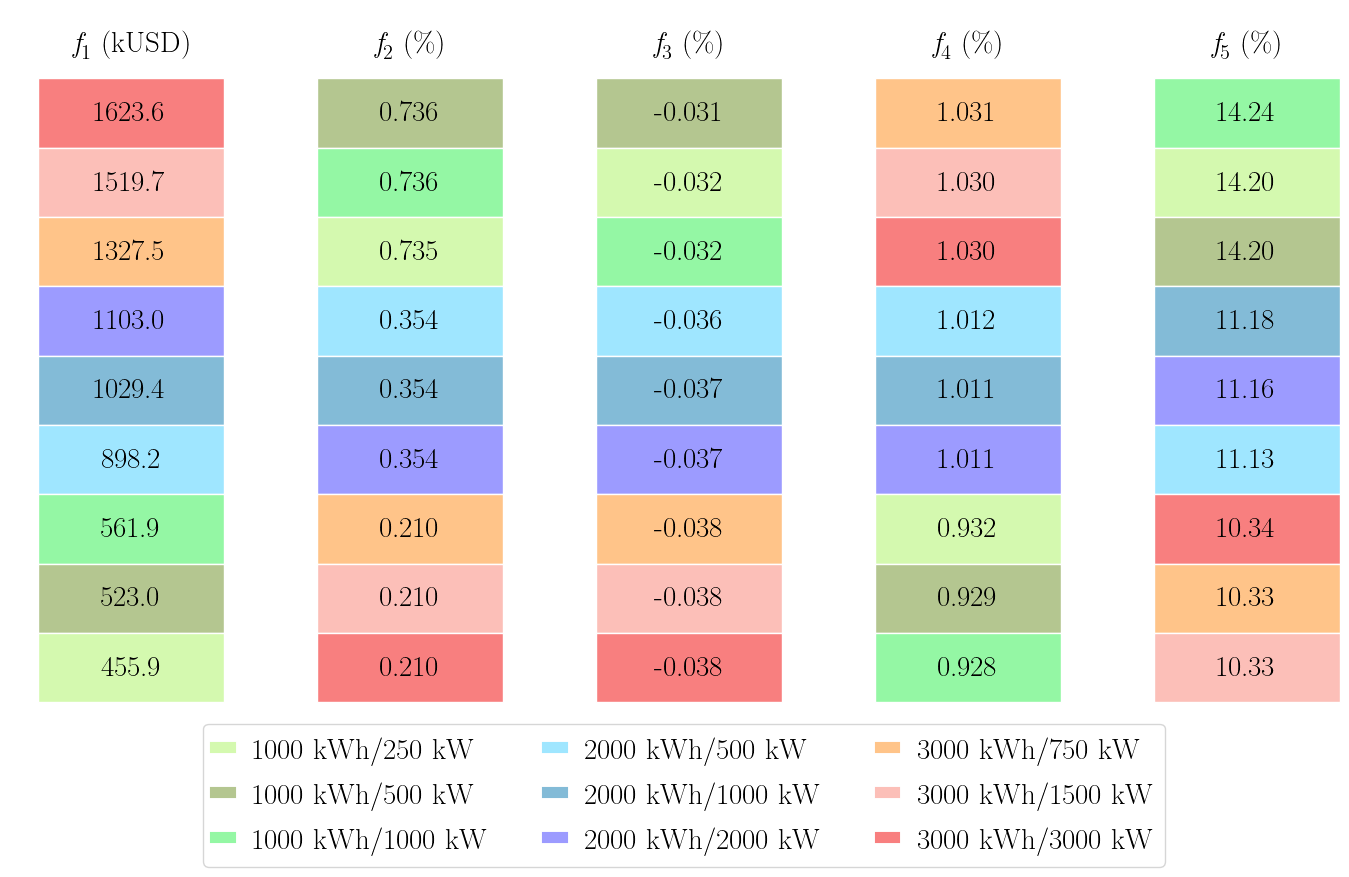

Gráfico PDF guardado en: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\PS_Fig_11_BESS_Option_Sizes\PS_Fig_11_BESS_Option_Sizesbus20284897to5064_20260428_103411.pdf
Existe PDF?: True
Gráfico SVG guardado en: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\PS_Fig_11_BESS_Option_Sizes\PS_Fig_11_BESS_Option_Sizesbus20284897to5064_20260428_103411.svg
Existe SVG?: True


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

e_alpha = 0.5
e_fontsize = 21 

primary_colors = {
    1: '#abf561', 2: '#6b8e23', 3: '#2af04b', 4: '#40cfff', 
    5: '#0979b0', 6: '#3b38ff', 7: '#ff8a14', 8: '#fa8072', 9: '#f30000'
}

# Asegurarse de que matplotlib use LaTeX
plt.rcParams['text.usetex'] = True  # Activar uso de LaTeX en matplotlib

# Crear una copia de los datos relevantes para el Parallel Plot
df_sizing = df_h_1to8760[['P_BESS', 'E_BESS', 'f1', 'f2', 'f3', 'f4','f5']].copy()
df_sizing['id'] = np.arange(1, 10)  # Genera un array de números del 1 al 9
df_BESS_id = df_sizing[['id', 'E_BESS', 'P_BESS']].copy()
print(f"df_BESS_id: \n{df_BESS_id}\n")

# Modificar las columnas f1, f2, f3, f4 para agregar las letras correspondientes
#df_sizing['f1'] = df_sizing['f1'].apply(lambda x: f"{(x/1000):.1f}")
df_sizing['f1'] = (df_sizing['f1'] / 1000).apply(lambda x: f"{x:.1f}")
df_sizing['f1'] = df_sizing['f1'].apply(lambda x: str(x).strip())  # Eliminar espacios
df_sizing['f1'] = pd.to_numeric(df_sizing['f1'], errors='coerce')  # Convertir a numérico

#df_sizing['f1'] = df_sizing['f1'].apply(lambda x: f"{x:.1f}")  # Agregar valores a la columna f2
df_sizing['f2'] = df_sizing['f2'].apply(lambda x: f"{x:.3f}")  # Agregar valores a la columna f2
df_sizing['f3'] = df_sizing['f3'].apply(lambda x: f"{x:.3f}")  # Agregar valores a la columna f3
df_sizing['f4'] = df_sizing['f4'].apply(lambda x: f"{x:.3f}")  # Agregar valores a la columna f4
df_sizing['f5'] = df_sizing['f5'].apply(lambda x: f"{x:.2f}")  # Agregar valores a la columna f4

# Ahora se actualiza df_f1, df_f2, df_f3, df_f4
df_f1 = df_sizing[['id', 'f1']].astype({'f1': 'float'}).sort_values(by='f1', ascending=False)
df_f2 = df_sizing[['id', 'f2']].astype({'f2': 'float'}).sort_values(by='f2', ascending=False)
df_f3 = df_sizing[['id', 'f3']].astype({'f3': 'float'}).sort_values(by='f3', ascending=False)
df_f4 = df_sizing[['id', 'f4']].astype({'f4': 'float'}).sort_values(by='f4', ascending=False)
df_f5 = df_sizing[['id', 'f5']].astype({'f5': 'float'}).sort_values(by='f5', ascending=False)

# Convertir a texto después de ordenar, solo para mostrar en la tabla
df_f1['f1'] = df_f1['f1'].apply(lambda x: f"{x:.1f}")
df_f2['f2'] = df_f2['f2'].apply(lambda x: f"{x:.3f}")
df_f3['f3'] = df_f3['f3'].apply(lambda x: f"{x:.3f}")
df_f4['f4'] = df_f4['f4'].apply(lambda x: f"{x:.3f}")
df_f5['f5'] = df_f5['f5'].apply(lambda x: f"{x:.2f}")

print(f"df_f1: \n{df_f1}\n")
print(f"df_f2: \n{df_f2}\n")

# Definir los encabezados con formato LaTeX
col_headers_1 = ['ID', r"$\textit{f}_1$ (years)", r"$\textit{f}_2$ (\%)", r"$\textit{f}_3$ (\%)", r"$\textit{f}_4$ (\%)"]

# Nombres personalizados para la segunda columna de cada DataFrame
col_headers_custom = [
    [r"$\textit{f}_1$ (kUSD)"],  # Para df_P_BESS
    [r"$\textit{f}_2$ (\%)"],  # Para df_f1
    [r"$\textit{f}_3$ (\%)"],     # Para df_f2
    [r"$\textit{f}_4$ (\%)"],     # Para df_f3
    [r"$\textit{f}_5$ (\%)"]      # Para df_f4
]

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, 9))

# Dibujar las tablas lado a lado con sus respectivos colores de fondo
tables = [df_f1, df_f2, df_f3, df_f4, df_f5]
x_offset = 0.5  # Para desplazar las tablas hacia la derecha

# Dibujar las tablas lado a lado con flechas al costado izquierdo
tables = [df_f1, df_f2, df_f3, df_f4, df_f5]
x_offset = 0  # Para desplazar las tablas hacia la derecha
line_offsets = [-0.5, -0.3, -0.1, 0.1, 0.2]  # Posiciones horizontales ajustadas para las flechas

# Iterar sobre los DataFrames y crear las tablas
for idx, df in enumerate(tables):

    # Dibujar flecha al costado izquierdo de cada DataFrame
    line_x = line_offsets[idx]
    line_y = [0, 1]  # Altura de la línea (de abajo hacia arriba)
    arrow_head_y = 1.05  # Posición de la punta de la flecha

    # # Línea vertical y flecha
    # ax.plot([line_x, line_x], line_y, color='black', lw=2)
    # ax.annotate('', xy=(line_x, arrow_head_y), xytext=(line_x, 1),
    #             arrowprops=dict(facecolor='black', arrowstyle='wedge,tail_width=0.5', lw=0))


    # Crear una copia temporal del DataFrame y eliminar 'id'
    df_temp = df.drop(columns=['id'])  # Solo eliminamos 'id' de la copia

    # Asignar encabezados personalizados para la segunda columna en cada DataFrame
    col_headers = col_headers_custom[idx]  # Solo usar el encabezado personalizado para cada DataFrame

    # Crear la tabla con los encabezados correspondientes
    table = ax.table(cellText=df_temp.values,  # Usar la copia sin 'id'
                    colLabels=col_headers,  # Encabezado personalizado sin 'ID'
                    loc='center', 
                    cellLoc='center', 
                    colLoc='center', 
                    bbox=[x_offset+ 0.03, 0, 0.20, 1])

    # Ajustar el tamaño de la fuente en las celdas y los encabezados
    for (i, j), cell in table.get_celld().items():
        cell.set_fontsize(e_fontsize)  # Ajustar tamaño de la fuente para todas las celdas y encabezados
        if i == 0:  # Las celdas del encabezado
            cell.set_facecolor('white')  # Fondo gris claro
            cell.set_edgecolor('white')  # Bordes blancos para los encabezados
        else:
            cell.set_edgecolor('white')  # Bordes blancos para las celdas restantes
    
    # Asignar los colores de fondo a las filas (solo para las filas de datos, no encabezado)
    for i, row in enumerate(df.values):  # Aún usamos el DataFrame original para asignar colores
        id_value = row[0]  # El valor del 'id' en la primera columna
        color = primary_colors[id_value]  # Obtener el color correspondiente al id
        color_rgba = mcolors.to_rgba(color, alpha=e_alpha)  # Convertir a color con alpha
        
        for j in range(1, df.shape[1]):  # Para cada celda (omitimos la columna 'id')
            cell = table[(i+1, j-1)]  # Ajustamos índices para reflejar el DataFrame modificado
            cell.set_facecolor(color_rgba)
            cell.set_edgecolor('white')  # Bordes blancos
    
    # Ajustar la posición de la tabla
    x_offset += 0.3  # Desplazar la siguiente tabla para que se muestre a la derecha

ax.axis('off')

# Guardar el gráfico como archivo PDF
output_path = 'DataFrames_colored.pdf'
plt.savefig(output_path, bbox_inches='tight', dpi=300)

###########

# Colores primarios asignados manualmente

primary_colors = ['#abf561', '#6b8e23', '#2af04b', 
                  '#40cfff', '#0979b0', '#3b38ff', 
                  '#ff8a14', '#fa8072', '#f30000']


df_BESS_id['Label'] = df_h_1to8760.apply(
    lambda row: f"{row['E_BESS']} kWh/{row['P_BESS']} kW",
    axis=1
)

unique_labels = df_BESS_id['Label'].unique()
color_map = dict(zip(unique_labels, primary_colors))

# Crear una leyenda agrupada correctamente
handles = [
    plt.Line2D([], [], color=color_map[label], lw=8, label=label, alpha=e_alpha)
    for label in unique_labels
]

# Posicionar la leyenda debajo del gráfico
plt.legend(
    handles=handles,
    bbox_to_anchor=(0.725, -0.01),  # Posición abajo
    loc='upper center',
    ncol=3,  # Número de columnas en la leyenda
    frameon=True,  # Sin borde en la leyenda
    fontsize=e_fontsize,
    handlelength=0.5,  # Longitud de las líneas en la leyenda
    handleheight=1  # Altura de los marcadores en la leyenda
    
)

######## Save image
output_dir = os.path.join(script_dir, f'{Svc}_Fig_11_BESS_Option_Sizes')
os.makedirs(output_dir, exist_ok=True)

now = datetime.now()
fecha_hora = now.strftime("%Y%m%d_%H%M%S")

primera_hora = 4897   # 24 de julio | 00 to 01
ultima_hora  = 5064   # 30 de julio | 23 to 24
P_BESS = 1000
E_BESS = 250

nombre_base = (
    f'{Svc}_Fig_11_BESS_Option_Sizes'
    f'{placement_optimal}'
    f'{primera_hora}to{ultima_hora}_'
    f'{fecha_hora}'
)

# Paths
output_path_pdf = os.path.abspath(
    os.path.join(output_dir, f'{nombre_base}.pdf')
)

output_path_svg = os.path.abspath(
    os.path.join(output_dir, f'{nombre_base}.svg')
)

# Save exactly the same figure in both formats
fig.savefig(output_path_pdf, bbox_inches='tight', dpi=300)
fig.savefig(output_path_svg, bbox_inches='tight', dpi=300)

plt.show()

print(f"Gráfico PDF guardado en: {output_path_pdf}")
print(f"Existe PDF?: {os.path.exists(output_path_pdf)}")

print(f"Gráfico SVG guardado en: {output_path_svg}")
print(f"Existe SVG?: {os.path.exists(output_path_svg)}")
